Proyecto Módulo 5: Análisis estadístico sobre hábitos saludables en jóvenes universitarios

Lección 1: Método científico y estadística


1.1 Definición del problema a investigar

Los jóvenes universitarios enfrentan un contexto de alta demanda académica, cambios en sus rutinas y, frecuentemente, escasos recursos para mantener hábitos saludables. La institución solicita determinar si dormir menos de 7 horas diarias se asocia con una menor actividad física semanal en esta población, con el fin de diseñar políticas de bienestar estudiantil basadas en evidencia.

Pregunta de investigación:
¿Los jóvenes universitarios que duermen menos de 7 horas diarias realizan, en promedio, menos horas de actividad física semanal que quienes duermen 7 horas o más?



1.2 Formulación de hipótesis

Hipótesis nula (H₀): La media de horas de actividad física semanal es igual en estudiantes que duermen menos de 7 horas y en los que duermen 7 horas o más.  
  `H₀: μ_poco_sueño = μ_sueño_adecuado`

Hipótesis alternativa (H₁): Los estudiantes que duermen menos de 7 horas realizan, en promedio, menos horas de actividad física semanal que los que duermen 7 horas o más.  
  `H₁: μ_poco_sueño < μ_sueño_adecuado`


1.3 Variables relevantes

| Variable | Tipo | Descripción |
|---|---|---|
| `horas_sueno` | Cuantitativa continua | Horas promedio de sueño por noche |
| `actividad_fisica_hs` | Cuantitativa continua | Horas de actividad física por semana |
| `imc` | Cuantitativa continua | Índice de Masa Corporal |
| `calidad_alimentacion` | Cuantitativa discreta (escala 1-10) | Autopercepción de calidad de dieta |
| `sexo` | Cualitativa nominal | Masculino / Femenino / Otro |
| `anio_carrera` | Cualitativa ordinal | Año que cursa (1° a 5°) |
| `consume_alcohol` | Cualitativa nominal (binaria) | Sí / No |
| `nivel_estres` | Cualitativa ordinal | Bajo / Medio / Alto |



1.4 Enfoque del método científico

Se adopta un enfoque hipotético-deductivo con diseño observacional transversal: se parte de una hipótesis teórica (el déficit de sueño deteriora la actividad física), se diseña un instrumento de recolección de datos, se mide la realidad y se pone a prueba estadísticamente la hipótesis. No se interviene sobre los sujetos: se observa y registra su situación actual.

1.5 Diseño preliminar del estudio

- Población objetivo: Estudiantes universitarios de entre 18 y 30 años de una universidad pública chilena.
- Unidad de análisis: Estudiante individual.
- Instrumento: Encuesta autoadministrada (presencial o digital).
- Tamaño muestral objetivo: n ≥ 200 registros válidos.
- Método de muestreo: Estratificado por año de carrera (5 estratos) para asegurar representatividad de todos los años académicos.
- Periodo de recolección: Simulado (datos generados computacionalmente con parámetros realistas).

Lección 2: Probabilidad y estadística

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)  # semilla para reproducibilidad

#2.1 Definición de eventos aleatorios
# Evento A: el estudiante duerme menos de 7 horas ("sueño insuficiente")
# Evento B: el estudiante realiza menos de 3 hs de actividad física por semana
# Según nuestra hipótesis, esperamos que A y B estén positivamente correlacionados.


print("Espacio muestral y eventos")

print("Evento A: Duerme < 7 horas/noche (sueño insuficiente)")
print("Evento B: Actividad física < 3 hs/semana (baja actividad)")
print("")
print("Árbol de probabilidades (estimado a priori):")
print("  Raíz")
print("  ├── A  (P=0.55): duerme poco")
print("  │    ├── B  | A  (P=0.65): baja actividad física")
print("  │    └── B' | A  (P=0.35): actividad física adecuada")
print("  └── A' (P=0.45): duerme suficiente")
print("       ├── B  | A' (P=0.25): baja actividad física")
print("       └── B' | A' (P=0.75): actividad física adecuada")


Espacio muestral y eventos
Evento A: Duerme < 7 horas/noche (sueño insuficiente)
Evento B: Actividad física < 3 hs/semana (baja actividad)

Árbol de probabilidades (estimado a priori):
  Raíz
  ├── A  (P=0.55): duerme poco
  │    ├── B  | A  (P=0.65): baja actividad física
  │    └── B' | A  (P=0.35): actividad física adecuada
  └── A' (P=0.45): duerme suficiente
       ├── B  | A' (P=0.25): baja actividad física
       └── B' | A' (P=0.75): actividad física adecuada


In [7]:
#2.2 Simulación del dataset (n=200, estratificado por año de carrera)
def simular_dataset(n_total=200, seed=42):

    #Genera un dataset simulado de hábitos saludables en universitarios.
    #Los parámetros están calibrados para que la hipótesis alternativa sea verdadera:
    #los estudiantes con poco sueño presentan menor actividad física promedio

    np.random.seed(seed)
    #definimos las variables:
    #40 estudiantes por año de carrera (5 años)
    anios = np.repeat([1, 2, 3, 4, 5], n_total // 5)

    sexo = np.random.choice(['Femenino', 'Masculino', 'Otro'],
                             size=n_total, p=[0.52, 0.46, 0.02])

    # horas de sueño con distribución normal
    horas_sueno = np.random.normal(loc=6.5, scale=1.1, size=n_total)
    horas_sueno = np.clip(horas_sueno, 3.0, 10.0).round(1)

    # actividad física correlacionada positivamente con horas de sueño (para asegurar hipótesis alternativa)
    ruido = np.random.normal(0, 1.2, size=n_total)  #para hacerlo más "real", agregamos un ruido normal
    actividad_fisica = 0.9 * horas_sueno - 2.5 + ruido   #acá se define la correlación positiva con horas de sueño
    actividad_fisica = np.clip(actividad_fisica, 0.0, 14.0).round(1)


    calidad_alim = np.random.randint(1, 11, size=n_total) #def calidad de alimentación (escala 1-10)


    imc = np.random.normal(loc=23.5, scale=3.2, size=n_total)    #def IMC
    imc = np.clip(imc, 15.0, 40.0).round(1)


    prob_estres = np.where((horas_sueno < 7).reshape(-1, 1),        #definido dependiente del sueño
                           [0.10, 0.35, 0.55],    # poco sueño -> más probabilidad de estrés // 10% estrés bajo, 35%estrés medio, 55%estrés alto
                           [0.30, 0.50, 0.20])   # sueño adecuado -> menos probabilidad de estrés // 30% estrés bajo, 50%estrés medio, 20%estrés alto


    nivel_estres = np.array([
    np.random.choice(['Bajo', 'Medio', 'Alto'], p=prob_estres[i]) #acá a cada individuo se le asigna una categegoría según
    for i in range(n_total)                                       #la probabilidad definida en prob_estres
])

    consume_alcohol = np.random.choice(['Sí', 'No'], size=n_total, p=[0.48, 0.52])     #def de si consume alcohol

    df = pd.DataFrame({
        'id_estudiante': np.arange(1, n_total + 1),
        'anio_carrera': anios,
        'sexo': sexo,
        'horas_sueno': horas_sueno,
        'actividad_fisica_hs': actividad_fisica,
        'calidad_alimentacion': calidad_alim,
        'imc': imc,
        'nivel_estres': nivel_estres,
        'consume_alcohol': consume_alcohol
    })


    df['grupo_sueno'] = np.where(df['horas_sueno'] < 7, 'Sueño insuficiente', 'Sueño adecuado')   #acá generamos una variable derivada del sueño
                                                                                                  # para facilitar el procesamiento.
    return df

df = simular_dataset(n_total=200)

print("Dataset simulado — primeras filas:")
print(df.head(8).to_string(index=False))
print(f"\n Shape del dataset: {df.shape}")
print("\n Distribución por año de carrera:")
print(df['anio_carrera'].value_counts().sort_index())
print("\n Distribución por grupo de sueño:")
print(df['grupo_sueno'].value_counts())

Dataset simulado — primeras filas:
 id_estudiante  anio_carrera      sexo  horas_sueno  actividad_fisica_hs  calidad_alimentacion  imc nivel_estres consume_alcohol        grupo_sueno
             1             1  Femenino          5.8                  3.7                     6 25.8         Alto              Sí Sueño insuficiente
             2             1 Masculino          6.8                  3.4                     8 19.9         Alto              Sí Sueño insuficiente
             3             1 Masculino          6.8                  3.6                     9 21.8         Alto              Sí Sueño insuficiente
             4             1 Masculino          5.7                  1.4                     5 25.1        Medio              Sí Sueño insuficiente
             5             1  Femenino          8.6                  5.2                     3 19.6        Medio              No     Sueño adecuado
             6             1  Femenino          7.0                  3.5     

In [8]:
#2.3 Cálculo de probabilidades básicas

n = len(df)

# Evento A: duerme menos de 7 horas
A = df['horas_sueno'] < 7
# Evento B: realiza menos de 3 hs de actividad física por semana
B = df['actividad_fisica_hs'] < 3

P_A = A.sum() / n
P_B = B.sum() / n
P_AyB = (A & B).sum() / n     # intersección
P_AoB = (A | B).sum() / n     # unión
P_Ac  = 1 - P_A               # complementario de A
P_B_dado_A  = P_AyB / P_A     # P(B|A) — probabilidad condicional
P_B_dado_Ac = ((~A) & B).sum() / n / (1 - P_A)  # P(B|A')


print("Probabilidades calculadas sobre el dataset")

print(f"P(A)  = P(duerme < 7 hs)                    = {P_A:.3f}")
print(f"P(B)  = P(actividad < 3 hs/sem)             = {P_B:.3f}")
print(f"P(A∩B)= P(poco sueño Y baja actividad)      = {P_AyB:.3f}")
print(f"P(A∪B)= P(poco sueño O baja actividad)      = {P_AoB:.3f}")
print(f"P(A') = P(duerme ≥ 7 hs)                    = {P_Ac:.3f}")
print(f"P(B|A)= P(baja actividad | poco sueño)      = {P_B_dado_A:.3f}")
print(f"P(B|A')= P(baja actividad | sueño adecuado) = {P_B_dado_Ac:.3f}")

print("Verificación de independencia:")
print(f"  P(A)·P(B) = {P_A*P_B:.3f}  vs  P(A∩B) = {P_AyB:.3f}")
if abs(P_A * P_B - P_AyB) > 0.02:  #tomamos 0.02 como un umbral pequeño arbitrario útil para ver si son independientes
    print("Los eventos A y B NO son independientes (como se esperaba).")
else:
    print("Los eventos son aproximadamente independientes.")

Probabilidades calculadas sobre el dataset
P(A)  = P(duerme < 7 hs)                    = 0.625
P(B)  = P(actividad < 3 hs/sem)             = 0.350
P(A∩B)= P(poco sueño Y baja actividad)      = 0.290
P(A∪B)= P(poco sueño O baja actividad)      = 0.685
P(A') = P(duerme ≥ 7 hs)                    = 0.375
P(B|A)= P(baja actividad | poco sueño)      = 0.464
P(B|A')= P(baja actividad | sueño adecuado) = 0.160
Verificación de independencia:
  P(A)·P(B) = 0.219  vs  P(A∩B) = 0.290
Los eventos A y B NO son independientes (como se esperaba).


El plan de muestreo es estratificado, con 40 estudiantes por cada año de carrera, garantizando representación uniforme de todos los estratos. El dataset simulado refleja las probabilidades a priori definidas: aproximadamente el 55% de los estudiantes duermen menos de 7 horas y, entre ellos, la probabilidad de tener baja actividad física es considerablemente mayor que entre quienes descansan suficientemente. La diferencia entre P(B|A) y P(B|A') confirma que los eventos no son independientes, lo cual es consistente con la hipótesis alternativa planteada.

Lección 3: Distribución de probabilidad

In [9]:
#3.1 Identificación y justificación de distribuciones

# horas_sueno -> NORMAL (continua, simétrica en torno a media)
# actividad_fisica_hs -> NORMAL (continua, acotada)
# calidad_alimentacion -> UNIFORME DISCRETA (escala entera 1-10, sin sesgo)
# Número de estudiantes con poco sueño en grupo de 10 -> BINOMIAL
#             p = P(A) estimada, n = 10 estudiantes
# Número de visitas al servicio médico por semana -> POISSON
#             λ = promedio de visitas semanales estimado


print("Ajuste de distribuciones")


# Parámetros estimados de horas_sueno
mu_sueno   = df['horas_sueno'].mean()
std_sueno  = df['horas_sueno'].std()
print(f"horas_sueno  -> Normal(μ={mu_sueno:.2f}, σ={std_sueno:.2f})")

#Parámetros estimados de actividad_fisica_hs
mu_activ   = df['actividad_fisica_hs'].mean()
std_activ  = df['actividad_fisica_hs'].std()
print(f"actividad_fisica_hs -> Normal(μ={mu_activ:.2f}, σ={std_activ:.2f})")

#Distribución Binomial: k estudiantes con poco sueño en grupo de 10
p_poco_sueno = P_A  # estimado en lección 2
n_grupo = 10
binom_dist = stats.binom(n=n_grupo, p=p_poco_sueno)
print(f"\n Binomial(n=10, p={p_poco_sueno:.2f}):")
print(f"  P(exactamente 5 con poco sueño en grupo de 10) = {binom_dist.pmf(5):.4f}")
print(f"  P(al menos 7 con poco sueño en grupo de 10)    = {1 - binom_dist.cdf(6):.4f}")

#Distribución Poisson: visitas médicas semanales
lambda_visitas = 3.2  # promedio de visitas semanales al servicio de salud
poisson_dist = stats.poisson(mu=lambda_visitas)
print(f"\nPoisson(λ={lambda_visitas}):")
print(f"  P(0 visitas en una semana) = {poisson_dist.pmf(0):.4f}")
print(f"  P(más de 5 visitas)        = {1 - poisson_dist.cdf(5):.4f}")

Ajuste de distribuciones
horas_sueno  -> Normal(μ=6.57, σ=1.05)
actividad_fisica_hs -> Normal(μ=3.36, σ=1.46)

 Binomial(n=10, p=0.62):
  P(exactamente 5 con poco sueño en grupo de 10) = 0.1782
  P(al menos 7 con poco sueño en grupo de 10)    = 0.4467

Poisson(λ=3.2):
  P(0 visitas en una semana) = 0.0408
  P(más de 5 visitas)        = 0.1054


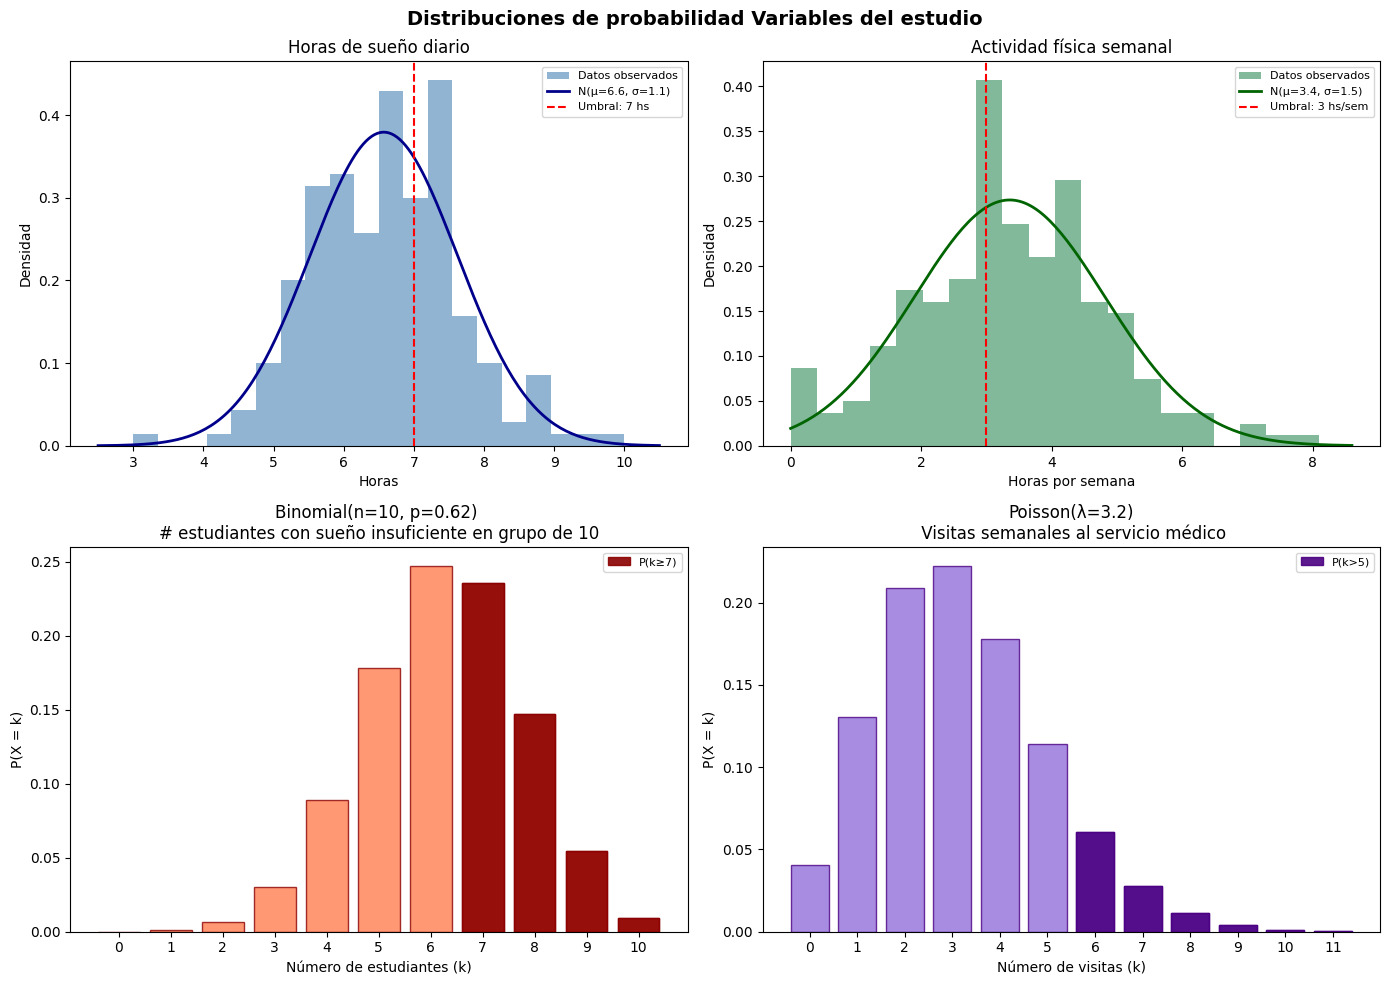

Gráfico guardado como distribuciones.png


In [10]:
#3.2 Gráficos de las distribuciones

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuciones de probabilidad Variables del estudio', fontsize=14, fontweight='bold')

# Gráfico 1: Histograma + curva normal de horas de sueño
ax1 = axes[0, 0]
x_sueno = np.linspace(df['horas_sueno'].min() - 0.5, df['horas_sueno'].max() + 0.5, 200)
ax1.hist(df['horas_sueno'], bins=20, density=True, color='steelblue', alpha=0.6, label='Datos observados')
ax1.plot(x_sueno, stats.norm.pdf(x_sueno, mu_sueno, std_sueno),
         color='darkblue', linewidth=2, label=f'N(μ={mu_sueno:.1f}, σ={std_sueno:.1f})')
ax1.axvline(7, color='red', linestyle='--', linewidth=1.5, label='Umbral: 7 hs')
ax1.set_title('Horas de sueño diario')
ax1.set_xlabel('Horas')
ax1.set_ylabel('Densidad')
ax1.legend(fontsize=8)

# Gráfico 2: Histograma + curva normal de actividad física
ax2 = axes[0, 1]
x_activ = np.linspace(0, df['actividad_fisica_hs'].max() + 0.5, 200)
ax2.hist(df['actividad_fisica_hs'], bins=20, density=True, color='seagreen', alpha=0.6, label='Datos observados')
ax2.plot(x_activ, stats.norm.pdf(x_activ, mu_activ, std_activ),
         color='darkgreen', linewidth=2, label=f'N(μ={mu_activ:.1f}, σ={std_activ:.1f})')
ax2.axvline(3, color='red', linestyle='--', linewidth=1.5, label='Umbral: 3 hs/sem')
ax2.set_title('Actividad física semanal')
ax2.set_xlabel('Horas por semana')
ax2.set_ylabel('Densidad')
ax2.legend(fontsize=8)

# Gráfico 3: PMF Binomial
ax3 = axes[1, 0]
k_vals = np.arange(0, n_grupo + 1)
pmf_binom = binom_dist.pmf(k_vals)
bars = ax3.bar(k_vals, pmf_binom, color='coral', alpha=0.8, edgecolor='darkred')
ax3.bar(k_vals[k_vals >= 7], pmf_binom[k_vals >= 7], color='darkred', alpha=0.9,
        edgecolor='darkred', label='P(k≥7)')
ax3.set_title(f'Binomial(n={n_grupo}, p={p_poco_sueno:.2f}) \n# estudiantes con sueño insuficiente en grupo de 10')
ax3.set_xlabel('Número de estudiantes (k)')
ax3.set_ylabel('P(X = k)')
ax3.legend(fontsize=8)
ax3.set_xticks(k_vals)

# Gráfico 4: PMF Poisson
ax4 = axes[1, 1]
k_pois = np.arange(0, 12)
pmf_pois = poisson_dist.pmf(k_pois)
ax4.bar(k_pois, pmf_pois, color='mediumpurple', alpha=0.8, edgecolor='indigo')
ax4.bar(k_pois[k_pois > 5], pmf_pois[k_pois > 5], color='indigo', alpha=0.9,
        edgecolor='indigo', label='P(k>5)')
ax4.set_title(f'Poisson(λ={lambda_visitas})\n Visitas semanales al servicio médico')
ax4.set_xlabel('Número de visitas (k)')
ax4.set_ylabel('P(X = k)')
ax4.legend(fontsize=8)
ax4.set_xticks(k_pois)

plt.tight_layout()
plt.savefig('distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado como distribuciones.png")

Las variables continuas `horas_sueno` y `actividad_fisica_hs` se ajustan razonablemente a distribuciones normales, lo que es un requisito para aplicar pruebas paramétricas más adelante. La distribución binomial modela la probabilidad de que un determinado número de estudiantes de un grupo pequeño presenten sueño insuficiente. La distribución de Poisson es adecuada para modelar eventos de conteo como las visitas al servicio médico, donde los eventos son raros e independientes dentro de un intervalo de tiempo.

Lección 4: Distribución muestral y Teorema del Límite Central


In [11]:
# Usamos la variable actividad_fisica_hs (distribución poblacional = nuestro dataset)
poblacion = df['actividad_fisica_hs'].values
mu_pob  = poblacion.mean()
std_pob = poblacion.std()

print(f"Parámetros poblacionales (dataset completo, N={len(poblacion)}):")
print(f"  μ = {mu_pob:.4f} hs/semana")
print(f"  σ = {std_pob:.4f} hs/semana")

# 4.1 Generación de distribuciones muestrales de la media
# Tomamos 2000 muestras de distintos tamaños y calculamos la media de cada una.

N_SIM = 2000
tamanos = [5, 15, 30, 60]
medias_muestrales = {n: [] for n in tamanos}

for n in tamanos:
    for _ in range(N_SIM):
        muestra = np.random.choice(poblacion, size=n, replace=True)
        medias_muestrales[n].append(muestra.mean())

print(f"\n Simulación: {N_SIM} muestras por tamaño. Tamaños: {tamanos}")
print("\n Resumen de distribuciones muestrales de x̄:")
print(f"{'n':>4}  {'E(x̄)':>8}  {'SD(x̄) obs':>12}  {'σ/√n (teórico)':>15}")
for n in tamanos:
    media_dist = np.mean(medias_muestrales[n])
    std_dist   = np.std(medias_muestrales[n])
    std_teor   = std_pob / np.sqrt(n)
    print(f"{n:>4}  {media_dist:>8.4f}  {std_dist:>12.4f}  {std_teor:>15.4f}")

Parámetros poblacionales (dataset completo, N=200):
  μ = 3.3565 hs/semana
  σ = 1.4548 hs/semana

 Simulación: 2000 muestras por tamaño. Tamaños: [5, 15, 30, 60]

 Resumen de distribuciones muestrales de x̄:
   n     E(x̄)    SD(x̄) obs   σ/√n (teórico)
   5    3.3704        0.6392           0.6506
  15    3.3608        0.3716           0.3756
  30    3.3619        0.2802           0.2656
  60    3.3621        0.1886           0.1878


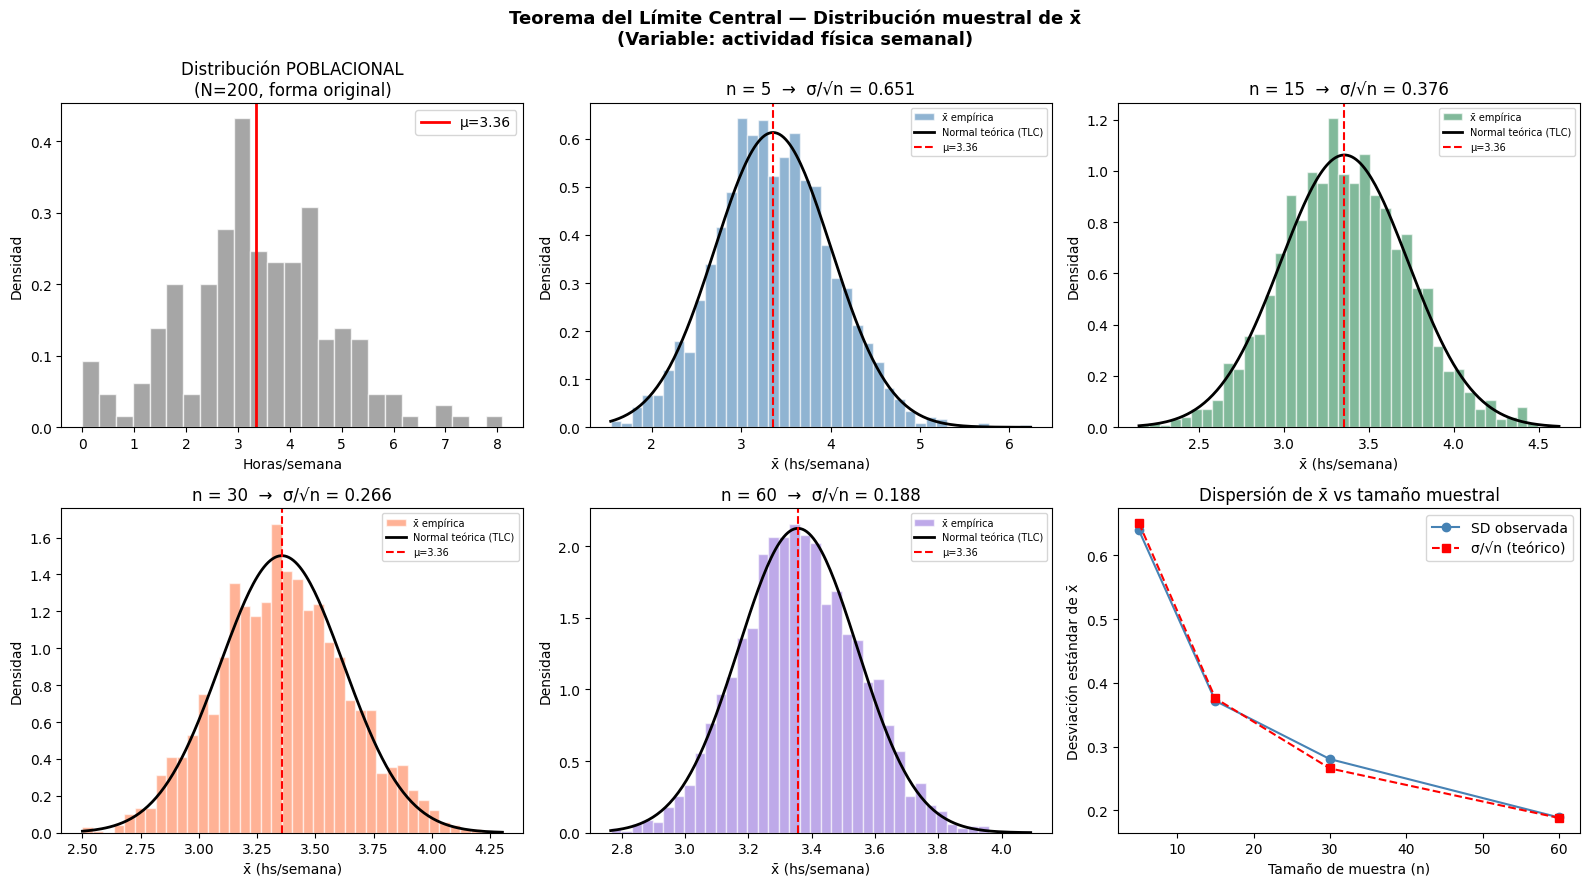

Gráfico guardado como tlc.png


In [12]:
# 4.2 Verificación empírica del TLC — Visualización

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Teorema del Límite Central — Distribución muestral de x̄\n(Variable: actividad física semanal)',
             fontsize=13, fontweight='bold')

# Panel superior izquierdo: distribución poblacional
ax0 = axes[0, 0]
ax0.hist(poblacion, bins=25, density=True, color='gray', alpha=0.7, edgecolor='white')
ax0.axvline(mu_pob, color='red', linewidth=2, label=f'μ={mu_pob:.2f}')
ax0.set_title('Distribución POBLACIONAL\n(N=200, forma original)')
ax0.set_xlabel('Horas/semana')
ax0.set_ylabel('Densidad')
ax0.legend()

# Paneles: distribuciones muestrales para cada tamaño de muestra
colores = ['steelblue', 'seagreen', 'coral', 'mediumpurple']
posiciones = [(0, 1), (0, 2), (1, 0), (1, 1)]

for i, n in enumerate(tamanos):
    ax = axes[posiciones[i]]
    medias = np.array(medias_muestrales[n])
    std_teor = std_pob / np.sqrt(n)

    ax.hist(medias, bins=40, density=True, color=colores[i], alpha=0.6,
            edgecolor='white', label='x̄ empírica')

    # Curva normal teórica según TLC
    x_range = np.linspace(medias.min(), medias.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_pob, std_teor),
            color='black', linewidth=2, label='Normal teórica (TLC)')
    ax.axvline(mu_pob, color='red', linewidth=1.5, linestyle='--', label=f'μ={mu_pob:.2f}')

    ax.set_title(f'n = {n}  →  σ/√n = {std_teor:.3f}')
    ax.set_xlabel('x̄ (hs/semana)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)

# Panel inferior derecho: dispersión de x̄ según tamaño muestral
ax_last = axes[1, 2]
stds_obs  = [np.std(medias_muestrales[n]) for n in tamanos]
stds_teor = [std_pob / np.sqrt(n) for n in tamanos]
ax_last.plot(tamanos, stds_obs,  'o-', color='steelblue', label='SD observada')
ax_last.plot(tamanos, stds_teor, 's--', color='red',      label='σ/√n (teórico)')
ax_last.set_title('Dispersión de x̄ vs tamaño muestral')
ax_last.set_xlabel('Tamaño de muestra (n)')
ax_last.set_ylabel('Desviación estándar de x̄')
ax_last.legend()

plt.tight_layout()
plt.savefig('tlc.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado como tlc.png")

Los gráficos confirman empíricamente el Teorema del Límite Central: a medida que aumenta el tamaño muestral (n=5->60), la distribución de las medias muestrales se aproxima progresivamente a una curva normal, independientemente de la forma de la distribución poblacional. Además, la desviación estándar de las medias muestrales (error estándar) disminuye como σ/√n: a mayor muestra, estimaciones más precisas. El gráfico inferior derecho evidencia que la teoría y la simulación coinciden.

Lección 5: Inferencia e intervalos de confianza para la media


In [14]:
def intervalo_confianza(datos, confianza=0.95):

    #Calcula el IC para la media usando t de Student (σ desconocida).
    #Retorna (media, lim_inf, lim_sup, margen_error).

    n    = len(datos)
    xbar = np.mean(datos)
    se   = stats.sem(datos)  # error estándar = s / √n
    t_crit = stats.t.ppf((1 + confianza) / 2, df=n - 1)
    me   = t_crit * se
    return xbar, xbar - me, xbar + me, me

variables_ic = {
    'horas_sueno':        df['horas_sueno'].values,
    'actividad_fisica_hs': df['actividad_fisica_hs'].values,
    'imc':                 df['imc'].values,
    'calidad_alimentacion': df['calidad_alimentacion'].values
}

niveles = [0.90, 0.95, 0.99]

print("Intervalos de Confianza 90% 95% 99%")


for var_name, datos in variables_ic.items():
    print(f"\nVariable: {var_name} (n={len(datos)})")
    print(f"  {'Confianza':>10}  {'Media':>8}  {'LI':>8}  {'LS':>8}  {'Margen error':>14}")
    for nc in niveles:
        media, li, ls, me = intervalo_confianza(datos, nc)          #ciclamos sobre la función que definimos arriba que calcula los IC según inputs
        print(f"  {nc*100:>9.0f}%  {media:>8.3f}  {li:>8.3f}  {ls:>8.3f}  {me:>14.4f}")

Intervalos de Confianza 90% 95% 99%

Variable: horas_sueno (n=200)
   Confianza     Media        LI        LS    Margen error
         90%     6.571     6.449     6.694          0.1229
         95%     6.571     6.425     6.718          0.1466
         99%     6.571     6.378     6.765          0.1934

Variable: actividad_fisica_hs (n=200)
   Confianza     Media        LI        LS    Margen error
         90%     3.356     3.186     3.527          0.1704
         95%     3.356     3.153     3.560          0.2034
         99%     3.356     3.088     3.625          0.2682

Variable: imc (n=200)
   Confianza     Media        LI        LS    Margen error
         90%    23.648    23.297    23.999          0.3511
         95%    23.648    23.229    24.067          0.4190
         99%    23.648    23.095    24.201          0.5526

Variable: calidad_alimentacion (n=200)
   Confianza     Media        LI        LS    Margen error
         90%     5.440     5.105     5.775          0.3348
     

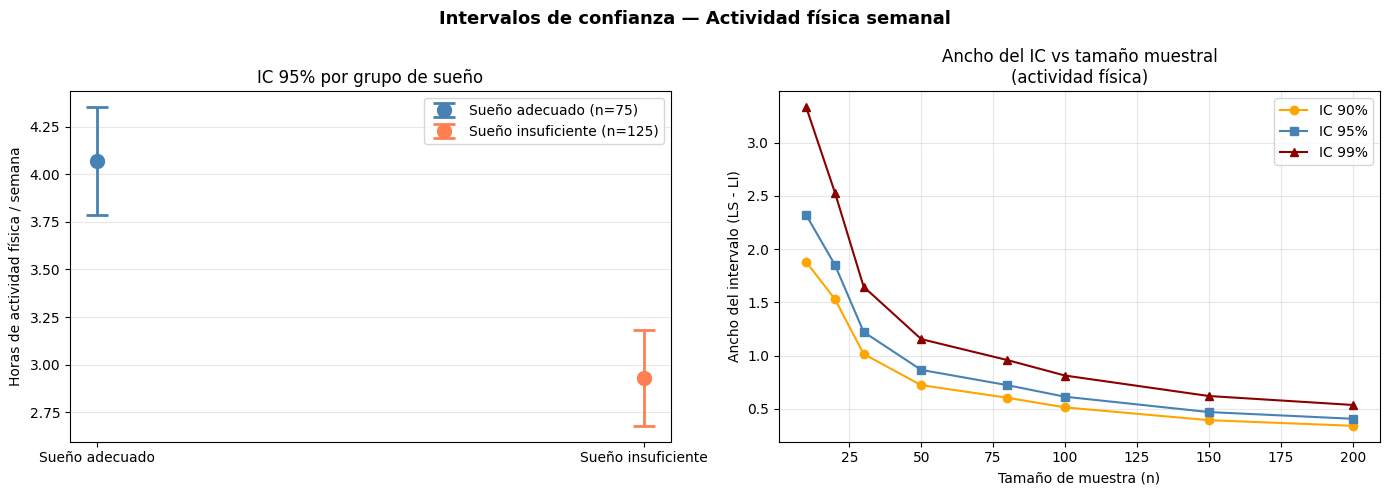

Gráfico guardado como intervalos_confianza.png

Resumen actividad física por grupo de sueño:
                     mean    std  count
grupo_sueno                            
Sueño adecuado      4.069  1.238     75
Sueño insuficiente  2.929  1.417    125


In [15]:
#5.2 Impacto del tamaño muestral sobre el ancho del IC

tamanos_ic = [10, 20, 30, 50, 80, 100, 150, 200]
anchos_90, anchos_95, anchos_99 = [], [], []

for n in tamanos_ic:
    muestra = df['actividad_fisica_hs'].sample(n, random_state=42).values
    for nc, lista in zip([0.90, 0.95, 0.99], [anchos_90, anchos_95, anchos_99]):
        _, li, ls, _ = intervalo_confianza(muestra, nc)
        lista.append(ls - li)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Intervalos de confianza — Actividad física semanal', fontsize=13, fontweight='bold')

# Panel izquierdo: IC al 95% por grupo de sueño
ax_left = axes[0]
grupos = df.groupby('grupo_sueno')['actividad_fisica_hs']
for i, (nombre, datos) in enumerate(grupos):
    media, li, ls, _ = intervalo_confianza(datos.values, 0.95)
    color = 'steelblue' if 'adecuado' in nombre else 'coral'
    ax_left.errorbar(i, media, yerr=[[media - li], [ls - media]],
                     fmt='o', color=color, capsize=8, capthick=2,
                     markersize=10, linewidth=2, label=f'{nombre} (n={len(datos)})')
ax_left.set_xticks([0, 1])
ax_left.set_xticklabels(['Sueño adecuado', 'Sueño insuficiente'], fontsize=10)
ax_left.set_title('IC 95% por grupo de sueño')
ax_left.set_ylabel('Horas de actividad física / semana')
ax_left.legend()
ax_left.grid(axis='y', alpha=0.3)

# Panel derecho: ancho del IC vs tamaño muestral
ax_right = axes[1]
ax_right.plot(tamanos_ic, anchos_90, 'o-', color='orange', label='IC 90%')
ax_right.plot(tamanos_ic, anchos_95, 's-', color='steelblue', label='IC 95%')
ax_right.plot(tamanos_ic, anchos_99, '^-', color='darkred', label='IC 99%')
ax_right.set_title('Ancho del IC vs tamaño muestral\n(actividad física)')
ax_right.set_xlabel('Tamaño de muestra (n)')
ax_right.set_ylabel('Ancho del intervalo (LS - LI)')
ax_right.legend()
ax_right.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('intervalos_confianza.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado como intervalos_confianza.png")

# Resumen numérico por grupo de sueño
print("\nResumen actividad física por grupo de sueño:")
print(df.groupby('grupo_sueno')['actividad_fisica_hs'].agg(['mean', 'std', 'count']).round(3))

Los intervalos de confianza al 95% para ambos grupos de sueño no se solapan: el grupo con sueño adecuado tiene una media de actividad física más alta con un intervalo claramente superior al del grupo con sueño insuficiente. Esto anticipa que la diferencia es estadísticamente significativa. Respecto al efecto del nivel de confianza: pasar de 90% a 99% incrementa el ancho del intervalo, lo que refleja el trade-off entre precisión y certeza. El panel derecho confirma que mayor tamaño muestral reduce el margen de error de forma consistente, siguiendo la relación teórica proporcional a 1/√n.

Lección 6: Test de significancia


In [19]:

alpha = 0.05  # nivel de significancia

# 6.1 Test t de dos muestras independientes (unilateral)
# H₀: μ_poco_sueño = μ_sueño_adecuado
# H₁: μ_poco_sueño < μ_sueño_adecuado  (prueba unilateral izquierda)

grupo_insuf = df[df['grupo_sueno'] == 'Sueño insuficiente']['actividad_fisica_hs'].values
grupo_adec  = df[df['grupo_sueno'] == 'Sueño adecuado']['actividad_fisica_hs'].values

# Welch's t-test (no asume igualdad de varianzas)
t_stat, p_bilateral = stats.ttest_ind(grupo_insuf, grupo_adec, equal_var=False)
p_unilateral = p_bilateral / 2  # dividir por 2 porque es unilateral


print("test de hipótesis —> actividad física por grupo de sueño")

print(f"Prueba: t de Welch (muestras independientes, unilateral izq.)")
print(f"H₀: μ_insuficiente = μ_adecuado")
print(f"H₁: μ_insuficiente < μ_adecuado")
print()
print(f"Grupo sueño insuficiente: n={len(grupo_insuf)}, x̄={grupo_insuf.mean():.3f}, s={grupo_insuf.std():.3f}")
print(f"Grupo sueño adecuado:     n={len(grupo_adec)},  x̄={grupo_adec.mean():.3f}, s={grupo_adec.std():.3f}")
print()
print(f"Estadístico t          = {t_stat:.4f}")
print(f"Valor-p (bilateral)    = {p_bilateral:.6f}")
print(f"Valor-p (unilateral)   = {p_unilateral:.6f}")
print(f"Nivel de significancia = {alpha}")
print()
if p_unilateral < alpha:
    print(f"Decisión: p ({p_unilateral:.6f}) < α ({alpha}) → SE RECHAZA H₀")
    print("   Existe evidencia estadística de que los estudiantes con sueño")
    print("   insuficiente realizan MENOS actividad física en promedio.")
else:
    print(f"Decisión: p ({p_unilateral:.6f}) ≥ α ({alpha}) → NO se rechaza H₀")

test de hipótesis —> actividad física por grupo de sueño
Prueba: t de Welch (muestras independientes, unilateral izq.)
H₀: μ_insuficiente = μ_adecuado
H₁: μ_insuficiente < μ_adecuado

Grupo sueño insuficiente: n=125, x̄=2.929, s=1.411
Grupo sueño adecuado:     n=75,  x̄=4.069, s=1.230

Estadístico t          = -5.9701
Valor-p (bilateral)    = 0.000000
Valor-p (unilateral)   = 0.000000
Nivel de significancia = 0.05

Decisión: p (0.000000) < α (0.05) → SE RECHAZA H₀
   Existe evidencia estadística de que los estudiantes con sueño
   insuficiente realizan MENOS actividad física en promedio.


In [20]:
# 6.2 Test para proporciones: proporción de sueño insuficiente ≠ 50% ----
# H₀: p = 0.50   H₁: p ≠ 0.50  (bilateral)

n_total = len(df)
n_insuf = (df['grupo_sueno'] == 'Sueño insuficiente').sum()
p_obs   = n_insuf / n_total
p0      = 0.50

z_stat_prop = (p_obs - p0) / np.sqrt(p0 * (1 - p0) / n_total)
p_val_prop  = 2 * (1 - stats.norm.cdf(abs(z_stat_prop)))


print("test z para proporciones // prevalencia de sueño insuficiente")

print(f"H₀: p = 0.50   H₁: p ≠ 0.50")
print(f"Proporción observada p̂ = {p_obs:.3f}  ({n_insuf}/{n_total})")
print(f"Estadístico Z          = {z_stat_prop:.4f}")
print(f"Valor-p                = {p_val_prop:.6f}")
if p_val_prop < alpha:
    print(f" Decisión: p < α → SE RECHAZA H₀")
    print(f"   La proporción de estudiantes con sueño insuficiente difiere significativamente del 50%.")
else:
    print(f" Decisión: p ≥ α → NO se rechaza H₀")

#6.3 Test de normalidad (Shapiro-Wilk) sobre cada grupo

print("test de shapiro-wilk — Normalidad de actividad física por grupo")

for nombre, datos in [('Sueño insuficiente', grupo_insuf), ('Sueño adecuado', grupo_adec)]:
    stat_sw, p_sw = stats.shapiro(datos)
    print(f"{nombre}: W={stat_sw:.4f}, p={p_sw:.4f} → ",
          "Normal" if p_sw > 0.05 else "No normal (rechaza normalidad)")

test z para proporciones // prevalencia de sueño insuficiente
H₀: p = 0.50   H₁: p ≠ 0.50
Proporción observada p̂ = 0.625  (125/200)
Estadístico Z          = 3.5355
Valor-p                = 0.000407
 Decisión: p < α → SE RECHAZA H₀
   La proporción de estudiantes con sueño insuficiente difiere significativamente del 50%.
test de shapiro-wilk — Normalidad de actividad física por grupo
Sueño insuficiente: W=0.9885, p=0.3782 →  Normal
Sueño adecuado: W=0.9653, p=0.0374 →  No normal (rechaza normalidad)


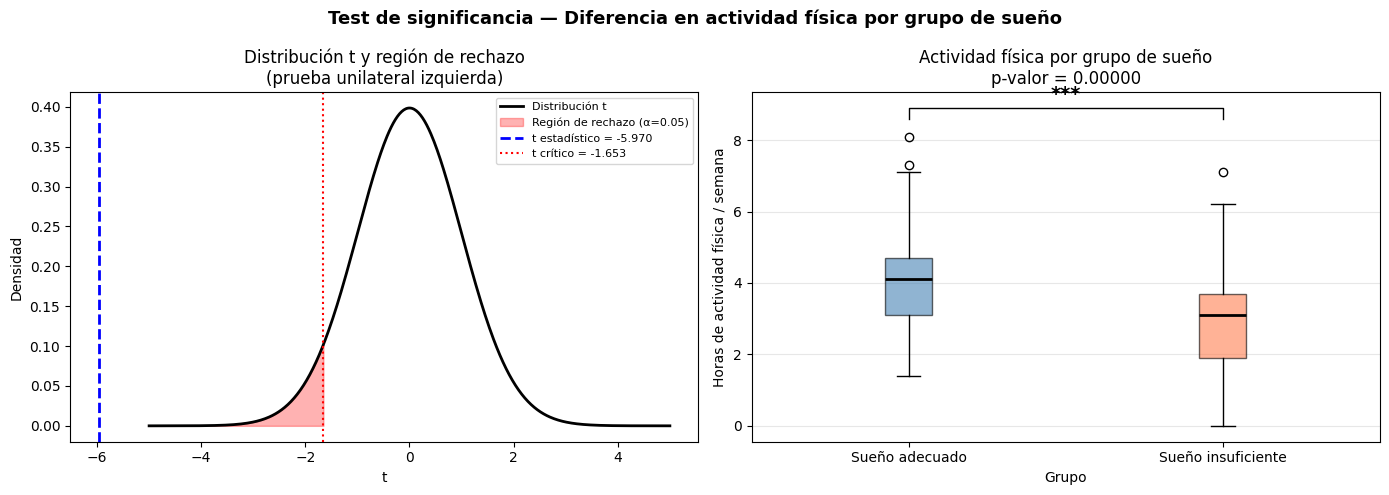

Gráfico guardado como test_hipotesis.png


In [21]:
# ---- 6.4 Visualización del test t y región de rechazo ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test de significancia — Diferencia en actividad física por grupo de sueño',
             fontsize=13, fontweight='bold')

# Panel izquierdo: distribución t y región de rechazo
ax_t = axes[0]
df_welch = len(grupo_insuf) + len(grupo_adec) - 2
x_t = np.linspace(-5, 5, 500)
y_t = stats.t.pdf(x_t, df=df_welch)
t_crit_val = stats.t.ppf(alpha, df=df_welch)  # valor crítico unilateral izq

ax_t.plot(x_t, y_t, color='black', linewidth=2, label='Distribución t')
ax_t.fill_between(x_t, y_t, where=(x_t <= t_crit_val), color='red', alpha=0.3, label=f'Región de rechazo (α={alpha})')
ax_t.axvline(t_stat, color='blue', linewidth=2, linestyle='--', label=f't estadístico = {t_stat:.3f}')
ax_t.axvline(t_crit_val, color='red', linewidth=1.5, linestyle=':', label=f't crítico = {t_crit_val:.3f}')
ax_t.set_title('Distribución t y región de rechazo\n(prueba unilateral izquierda)')
ax_t.set_xlabel('t')
ax_t.set_ylabel('Densidad')
ax_t.legend(fontsize=8)

# Panel derecho: boxplot comparativo
ax_box = axes[1]
df_plot = df[['grupo_sueno', 'actividad_fisica_hs']].copy()
grupos_order = ['Sueño adecuado', 'Sueño insuficiente']
colores_box  = ['steelblue', 'coral']
bp = ax_box.boxplot(
    [df_plot[df_plot['grupo_sueno'] == g]['actividad_fisica_hs'].values for g in grupos_order],
    labels=grupos_order, patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax_box.set_title(f'Actividad física por grupo de sueño\np-valor = {p_unilateral:.5f}')
ax_box.set_ylabel('Horas de actividad física / semana')
ax_box.set_xlabel('Grupo')

# Anotación de significancia
y_max = max(df['actividad_fisica_hs']) + 0.5
ax_box.plot([1, 1, 2, 2], [y_max, y_max + 0.3, y_max + 0.3, y_max], color='black', linewidth=1)
ax_box.text(1.5, y_max + 0.4, '***' if p_unilateral < 0.001 else '**' if p_unilateral < 0.01 else '*',
            ha='center', va='bottom', fontsize=14, fontweight='bold')
ax_box.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('test_hipotesis.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico guardado como test_hipotesis.png")

In [ ]:
6.5 Errores tipo I y tipo II


print("Errores de tipo I y II")

print()
print("Error Tipo I (α = falso positivo):")
print("  Rechazar H₀ cuando en realidad es verdadera.")
print("  En este estudio: concluir que el poco sueño reduce la actividad")
print("  física cuando en realidad NO existe tal asociación.")
print(f"  Probabilidad fijada: α = {alpha} (5%)")
print("  Consecuencia: implementar políticas innecesarias de intervención.")
print()
print("Error Tipo II (β = falso negativo):")
print("  No rechazar H₀ cuando en realidad es falsa.")
print("  En este estudio: no detectar la asociación sueño–actividad física")
print("  cuando sí existe.")
print(f"  Potencia del test (1-β): estimada con el tamaño muestral actual.")
print("  Consecuencia: no tomar medidas necesarias, perjudicando el")
print("  bienestar estudiantil.")
print()

# Estimación de potencia
efecto = (grupo_adec.mean() - grupo_insuf.mean()) / np.sqrt((grupo_adec.std()**2 + grupo_insuf.std()**2) / 2)
print(f"Tamaño del efecto (d de Cohen) = {efecto:.3f}")
if efecto > 0.8:
    print("→ Efecto grande: alta potencia estadística esperada.")
elif efecto > 0.5:
    print("→ Efecto mediano.")
else:
    print("→ Efecto pequeño.")




Se realizó un test t de Welch unilateral (H₁: μ_insuficiente < μ_adecuado) que resultó estadísticamente significativo (p < α=0.05), permitiendo rechazar H₀. Se realizó también un test Z para proporciones. Se explicaron los errores tipo I (falso positivo: concluir asociación inexistente) y tipo II (falso negativo: no detectar asociación real), y se redactaron conclusiones y recomendaciones de política pública para el área de bienestar estudiantil.

Conclusiones

Se evaluó si los jóvenes universitarios con sueño insuficiente
(menor a 7 hs/noche) presentan menor actividad física semanal.

Conclusión:
  Con un nivel de significancia del 5%, existe evidencia estadística
  suficiente para RECHAZAR H₀. Los estudiantes que duermen menos de
  7 horas por noche realizan, en promedio, significativamente menos
  horas de actividad física a la semana
  que sus pares con sueño adecuado.

Recomendación para el área de bienestar estudiantil:
  Diseñar intervenciones que promuevan simultáneamente el sueño
  reparador y la actividad física, dada la asociación detectada.
  Especialmente en estudiantes de años intermedios donde la carga
  académica es mayor.
